#**Preprocesamiento y exploracionde datos**
Ajuste el contenido anterior a un dataset incluido en scikit-learn.
Usamos el dataset Iris de scikit-learn: 150 muestras de flores de lirio entre 3 especies (Setosa, Versicolor, Virginia) descritas por 4 variables (Longitud del sépalo, Ancho del sépalo, Longitud de pétalo, Ancho del pétalo)

# **Configuración inicial**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
np.random.seed(42)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


# **Carga de datos**

In [2]:
datos = load_iris()
df = pd.DataFrame(datos.data, columns=datos.feature_names)
df["clase"] = datos.target
df["clase_nombre"] = df["clase"].map(dict(enumerate(datos.target_names)))

print(f"Forma del dataset: {df.shape}")
df.head()

Forma del dataset: (150, 6)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),clase,clase_nombre
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


# **Exploración inicial**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   clase              150 non-null    int64  
 5   clase_nombre       150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal width (cm),150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal length (cm),150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal width (cm),150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5
clase,150.0,1.000000,0.819232,0.0,0.0,1.00,2.0,2.0


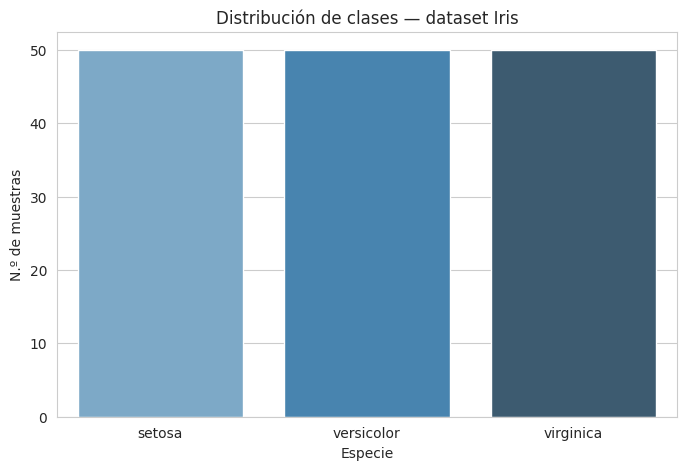

clase_nombre
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [5]:
conteo_clases = df["clase_nombre"].value_counts()

plt.figure()
sns.barplot(
    x=conteo_clases.index,
    y=conteo_clases.values,
    hue=conteo_clases.index,
    palette="Blues_d",
    legend=False,
)
plt.title("Distribución de clases — dataset Iris")  # <-- Cambiado "Wine" por "Iris"
plt.ylabel("N.º de muestras")
plt.xlabel(
    "Especie"
)  # <-- Cambiado "Cultivar" por "Especie" (Setosa, Versicolor, Virginica)
plt.show()

print(conteo_clases)

# **Visualización exploratoria(EDA)**

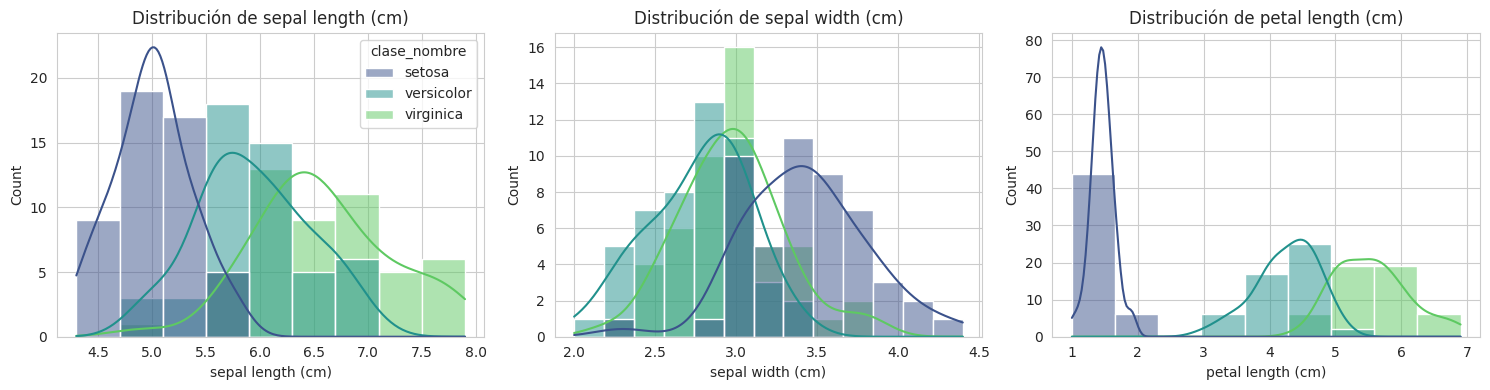

In [6]:
fig, ejes = plt.subplots(1, 3, figsize=(15, 4))

# Columnas de Iris: 'sepal length (cm)', 'sepal width (cm)', 'petal length (cm)'
columnas_iris = [
    "sepal length (cm)",
    "sepal width (cm)",
    "petal length (cm)",
]  # <-- Cambiado

for ax, col in zip(ejes, columnas_iris):
  sns.histplot(
      data=df,
      x=col,
      hue="clase_nombre",
      kde=True,
      ax=ax,
      palette="viridis",
      legend=(col == columnas_iris[0]),
  )
  ax.set_title(f"Distribución de {col}")

plt.tight_layout()
plt.show()

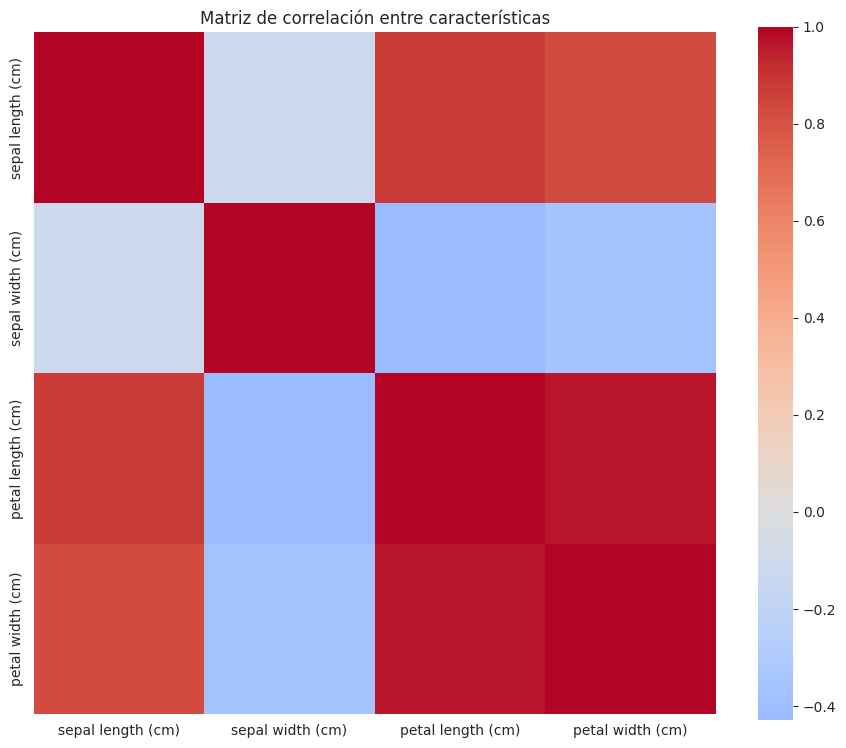

In [7]:
plt.figure(figsize=(11, 9))
correlacion = df[datos.feature_names].corr()
sns.heatmap(correlacion, cmap="coolwarm", center=0, annot=False, square=True)
plt.title("Matriz de correlación entre características")
plt.show()

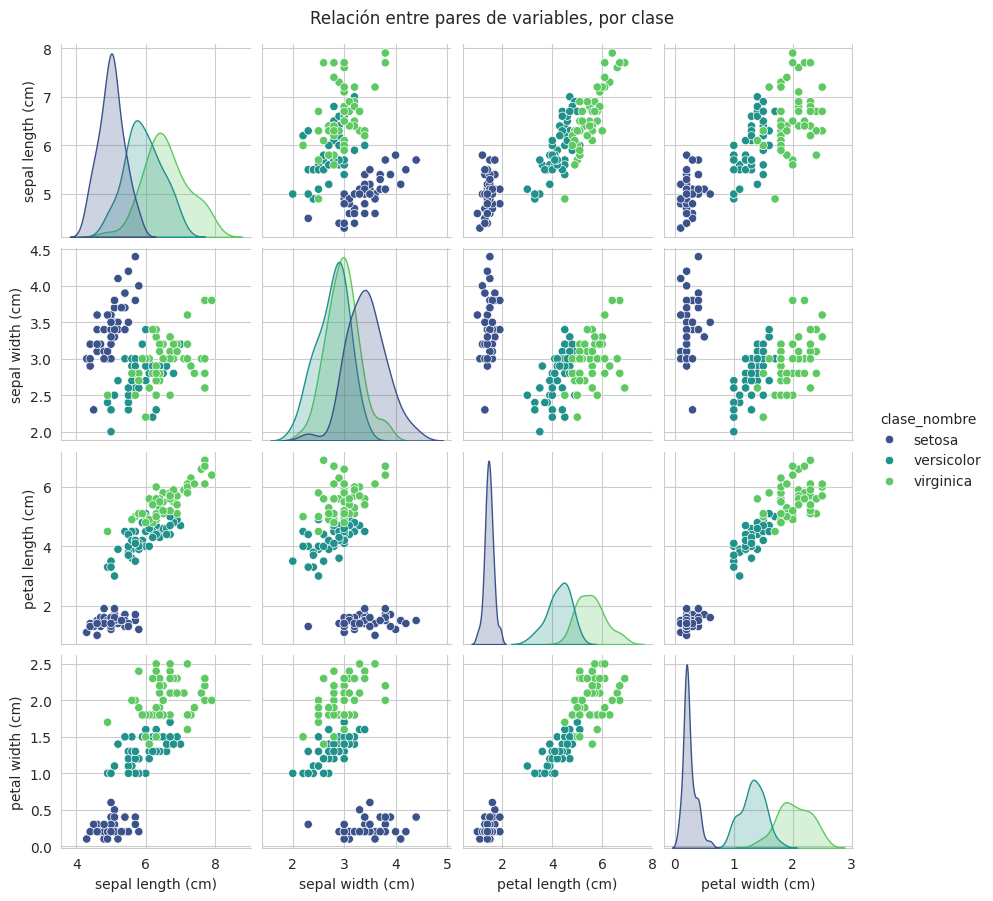

In [8]:
subset = [
    "sepal length (cm)",
    "sepal width (cm)",
    "petal length (cm)",
    "petal width (cm)",
    "clase_nombre",
]  # <-- Cambiado
sns.pairplot(
    df[subset],
    hue="clase_nombre",
    palette="viridis",
    diag_kind="kde",
    height=2.2,
)
plt.suptitle("Relación entre pares de variables, por clase", y=1.02)
plt.show()

# **Detección de valores atípicos (outliers)**

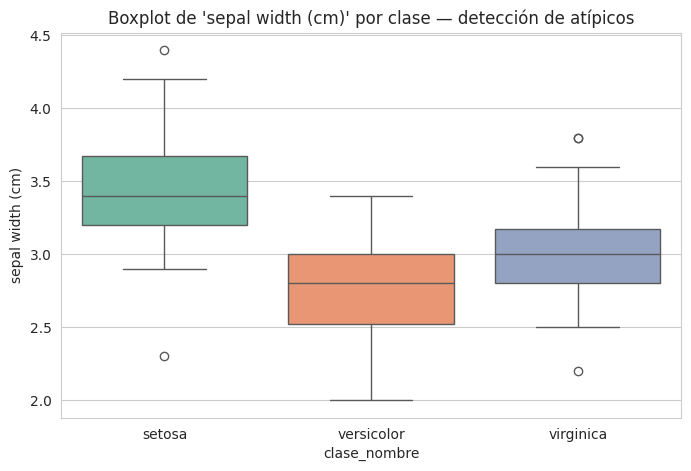

In [9]:
plt.figure()
sns.boxplot(
    data=df,
    x="clase_nombre",
    y="sepal width (cm)",
    hue="clase_nombre",
    palette="Set2",
    legend=False,
)  # <-- Cambiado
plt.title("Boxplot de 'sepal width (cm)' por clase — detección de atípicos")
plt.show()

In [10]:
def detectar_outliers_iqr(serie):
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    limite_inf, limite_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return (serie < limite_inf) | (serie > limite_sup)

outliers_totales = pd.Series(False, index=df.index)
for col in datos.feature_names:
    outliers_totales |= detectar_outliers_iqr(df[col])

print(f"Muestras con al menos un valor atípico: {outliers_totales.sum()} de {len(df)}")
df[outliers_totales].head()

Muestras con al menos un valor atípico: 4 de 150


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),clase,clase_nombre
15,5.7,4.4,1.5,0.4,0,setosa
32,5.2,4.1,1.5,0.1,0,setosa
33,5.5,4.2,1.4,0.2,0,setosa
60,5.0,2.0,3.5,1.0,1,versicolor


# **Valores faltantes**

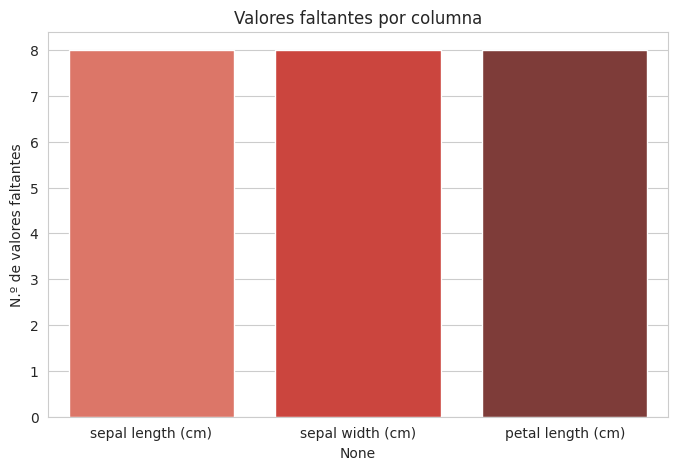

In [13]:
df_con_nulos = df.copy()
rng = np.random.default_rng(42)

for col in ["sepal length (cm)", "sepal width (cm)", "petal length (cm)"]:
  idx_nulos = rng.choice(df_con_nulos.index, size=8, replace=False)
  df_con_nulos.loc[idx_nulos, col] = np.nan
faltantes = df_con_nulos[datos.feature_names].isna().sum()
faltantes = faltantes[faltantes > 0]

plt.figure()
sns.barplot(x=faltantes.index, y=faltantes.values, hue=faltantes.index, palette="Reds_d", legend=False)
plt.title("Valores faltantes por columna")
plt.ylabel("N.º de valores faltantes")
plt.show()


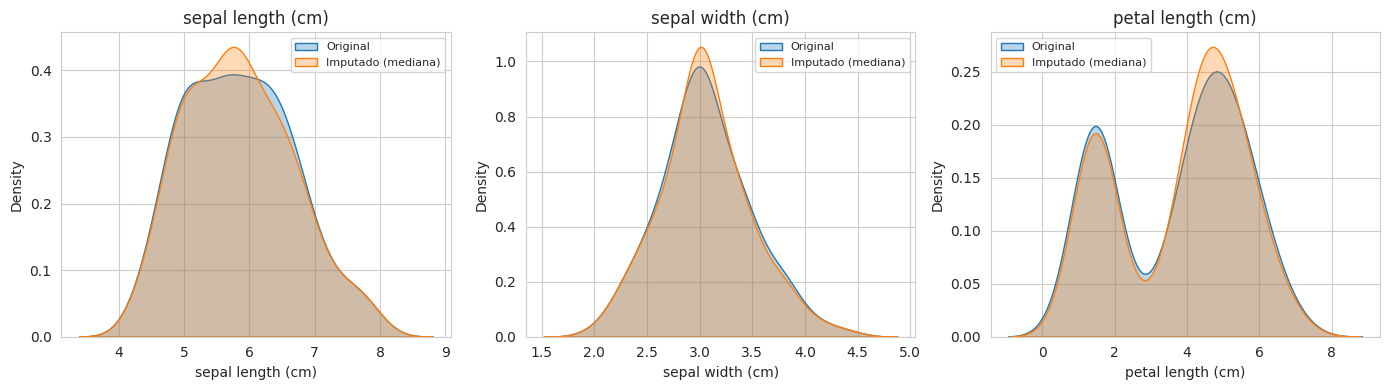

Valores faltantes tras la imputación: 0


In [14]:
imputador = SimpleImputer(strategy="median")
columnas_con_nulos = list(faltantes.index)

antes = df_con_nulos[columnas_con_nulos].copy()
df_imputado = df_con_nulos.copy()
df_imputado[columnas_con_nulos] = imputador.fit_transform(df_con_nulos[columnas_con_nulos])

fig, ejes = plt.subplots(1, len(columnas_con_nulos), figsize=(14, 4))
for ax, col in zip(ejes, columnas_con_nulos):
    sns.kdeplot(df[col], ax=ax, label="Original", fill=True, alpha=0.3)
    sns.kdeplot(df_imputado[col], ax=ax, label="Imputado (mediana)", fill=True, alpha=0.3)
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print("Valores faltantes tras la imputación:", df_imputado[columnas_con_nulos].isna().sum().sum())

# **Escalado de características**

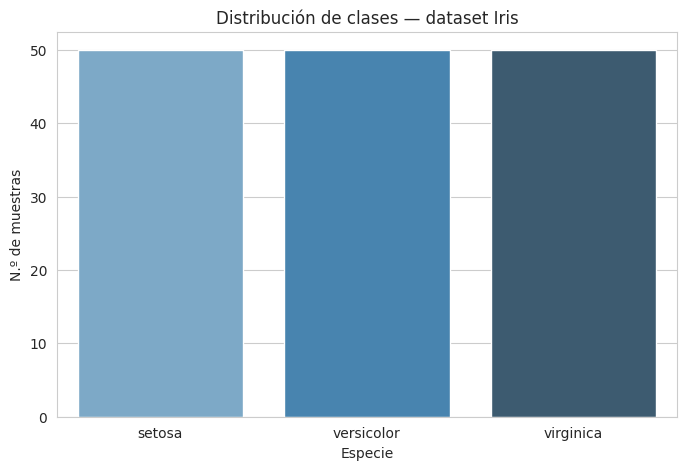

clase_nombre
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [16]:
conteo_clases = df["clase_nombre"].value_counts()

plt.figure()
sns.barplot(
    x=conteo_clases.index,
    y=conteo_clases.values,
    hue=conteo_clases.index,
    palette="Blues_d",
    legend=False,
)
plt.title("Distribución de clases — dataset Iris")  # <-- Cambiado "Wine" por "Iris"
plt.ylabel("N.º de muestras")
plt.xlabel(
    "Especie"
)  # <-- Cambiado "Cultivar" por "Especie" (Setosa, Versicolor, Virginica)
plt.show()

print(conteo_clases)